
>>> Generating CHH Grid (37 cases)...


100%|██████████| 37/37 [00:11<00:00,  3.27it/s]


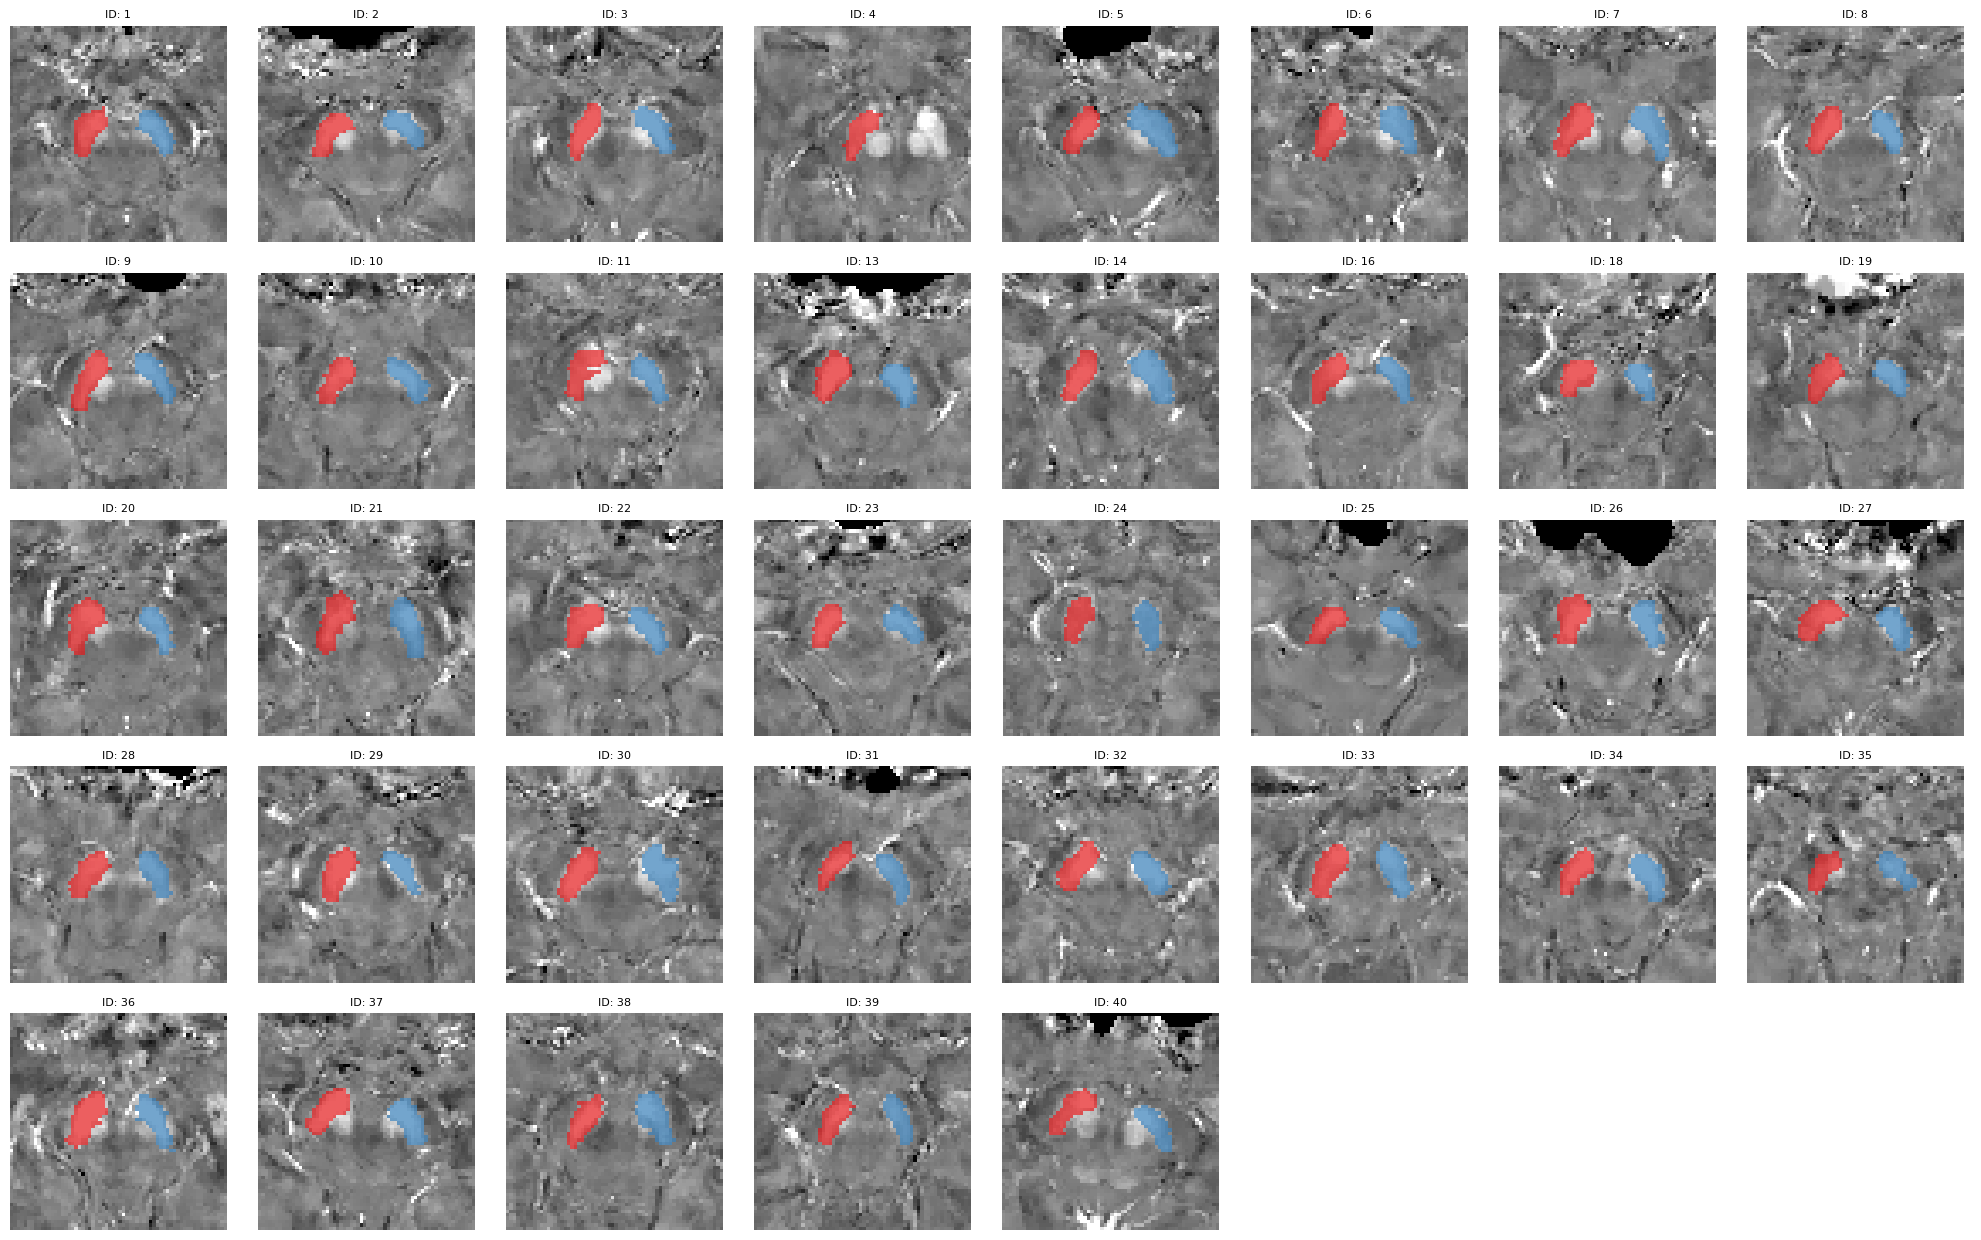


>>> Generating MSW Grid (111 cases)...


100%|██████████| 111/111 [20:20<00:00, 11.00s/it]


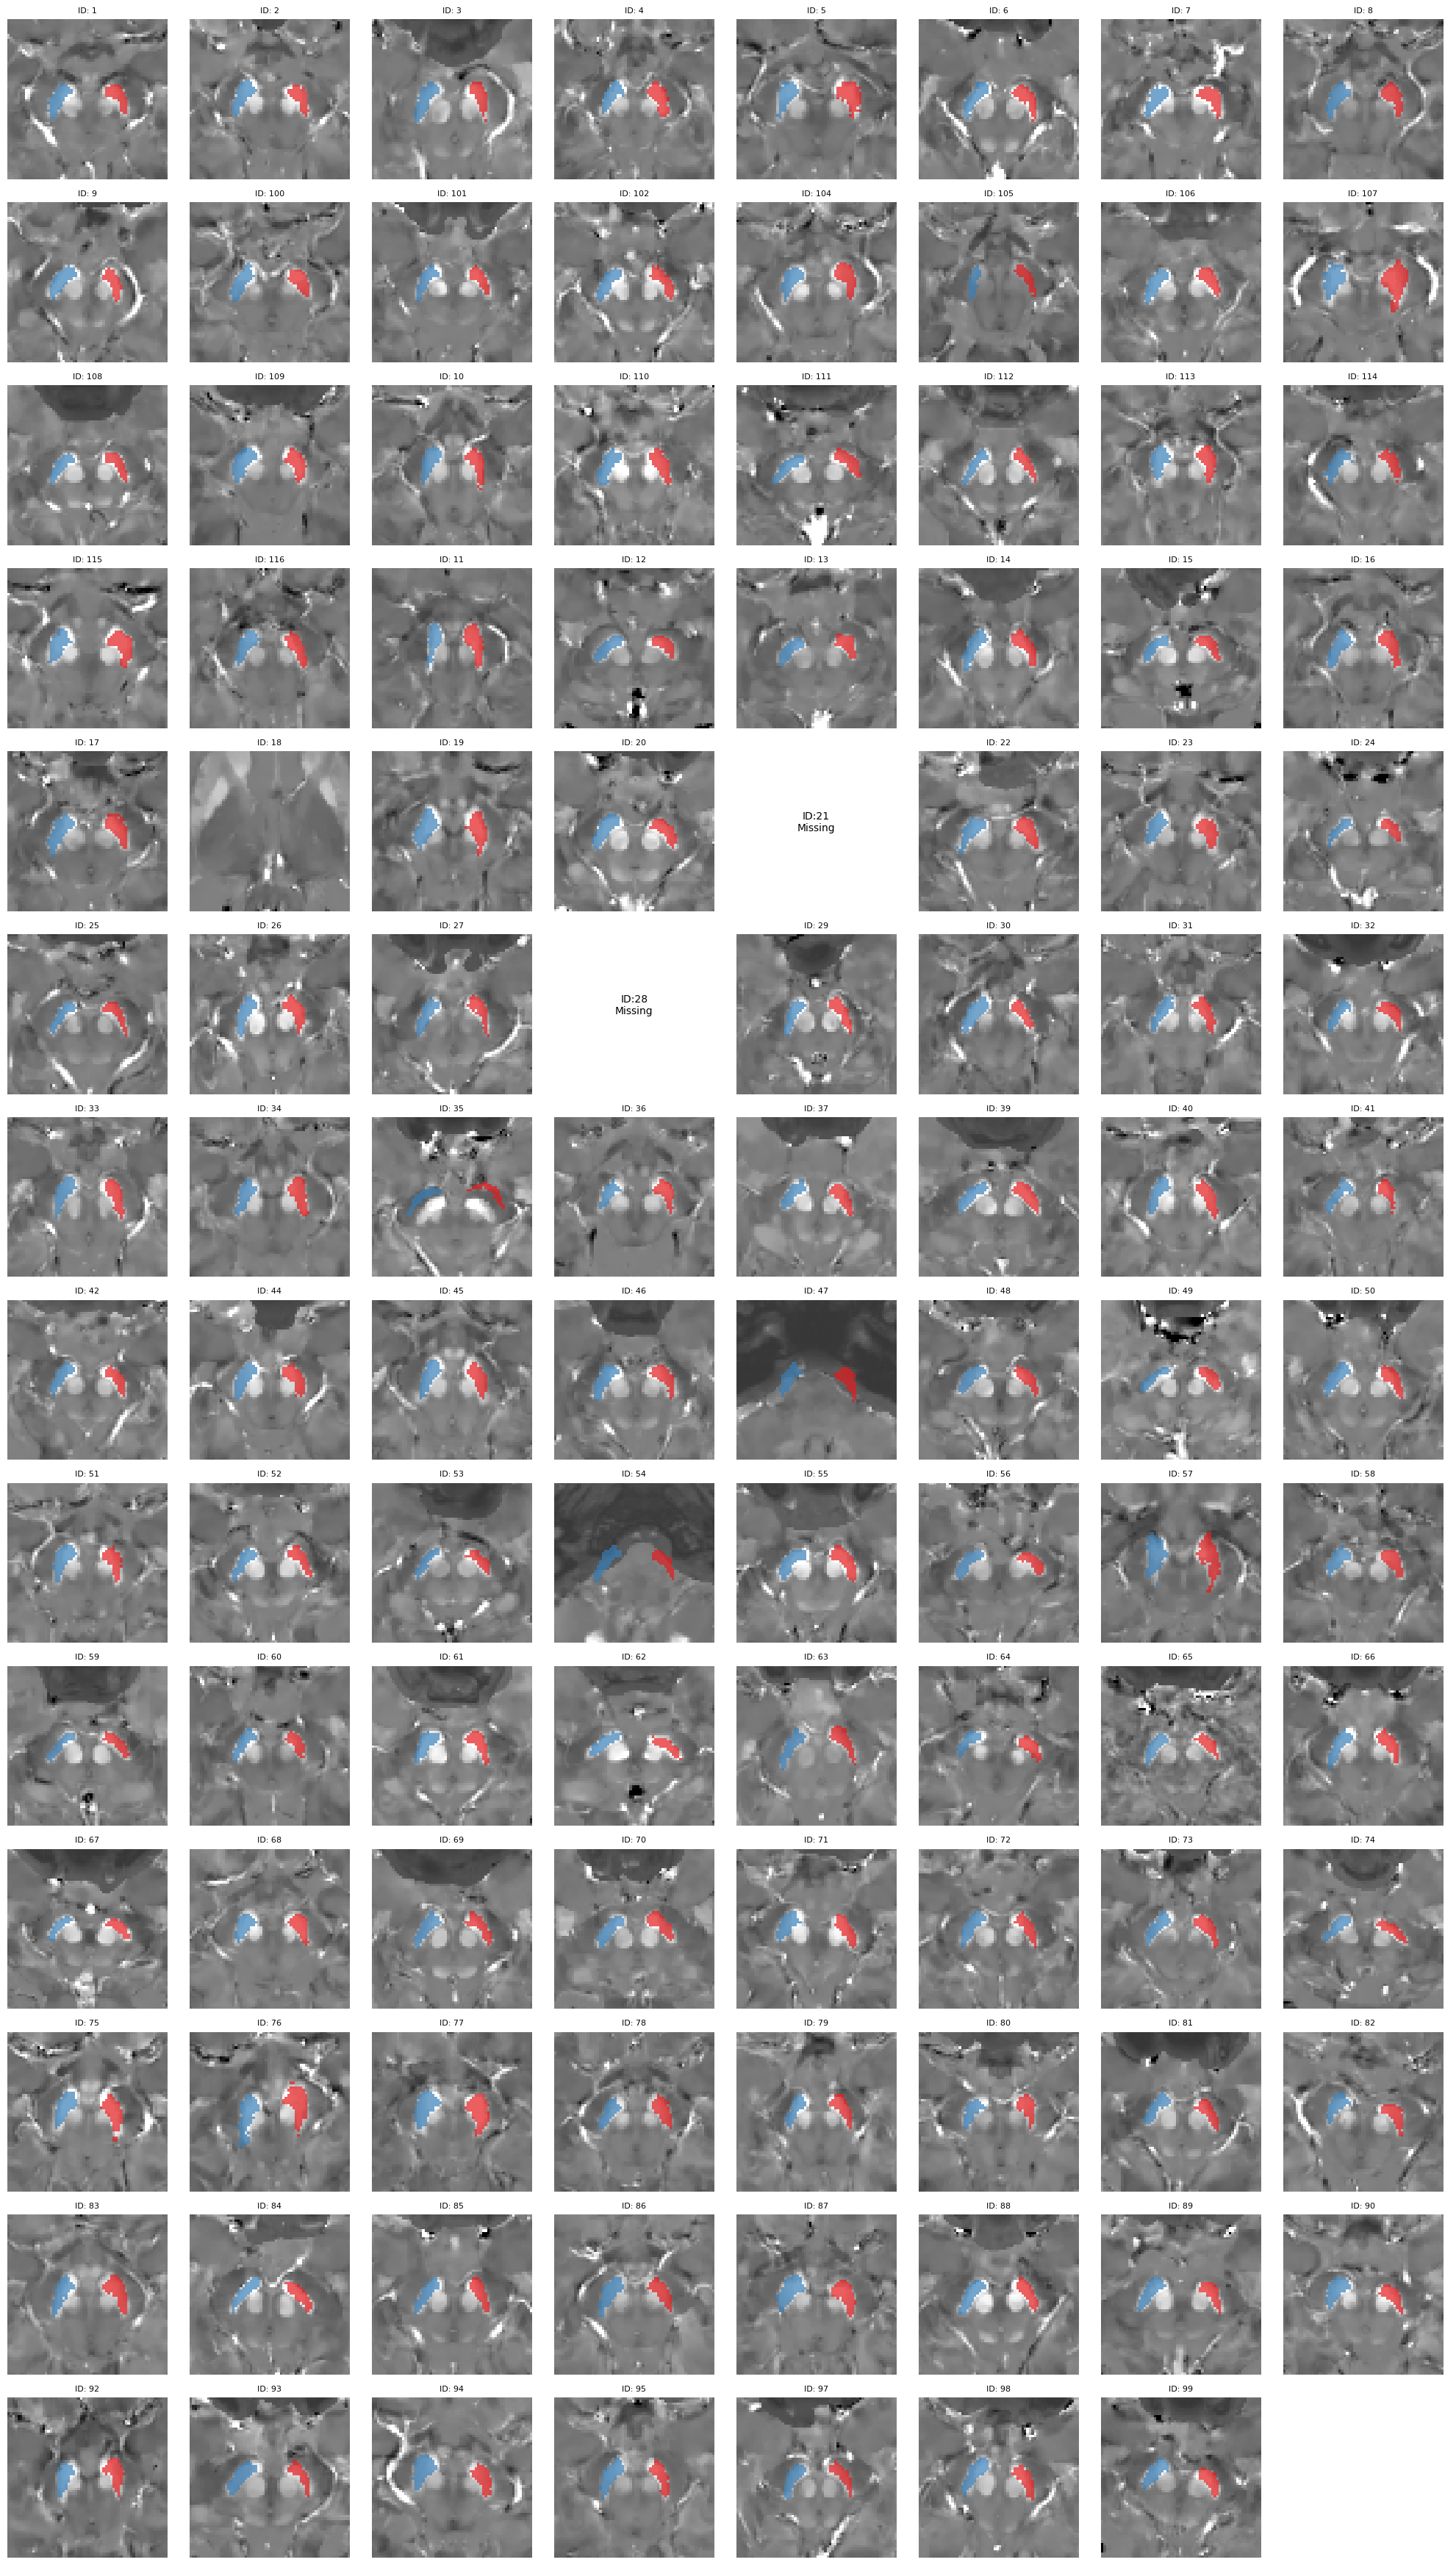

Saving MSW PNGs: 100%|██████████| 111/111 [00:00<00:00, 14938.80it/s]


In [1]:
import os
import re
import math
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from joblib import Parallel, delayed
from tqdm import tqdm
import pandas as pd

# --- Configuration ---
MSW_IMG_DIR = '/media/mts_dbs/dbs/all/nii/qsm_115/im'
MSW_SEG_DIR = '/media/mts_dbs/dbs/all/nii/seg_ps/'
CHH_IMG_DIR = '/media/mts_dbs/chh/nii/qsm/'
CHH_SEG_DIR = '/media/mts_dbs/chh/nii/roi/'
SAVE_DIR = "/media/mts_dbs/processed_arrays"
MSW_CSV = '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv'
CHH_CSV = '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv'

TARGET_SHAPE = (64, 64, 72)
PLOT_OUTPUT_DIR = "./centering_checks"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

# --- Metadata Functions ---
def get_clinical_metadata():
    clinical_dict, label_map = {}, {}
    try:
        df_chh = pd.read_csv(CHH_CSV, header=None)
        for _, row in df_chh.iloc[2:].iterrows():
            if pd.isna(row[0]): continue 
            sub_id = str(int(float(row[0])))
            vec = [row[1], row[2], row[3], row[4], row[9], row[10]]
            clinical_dict[sub_id] = np.nan_to_num(np.array(vec, dtype=np.float32))
            off_p, post_p = pd.to_numeric(row[9], errors='coerce'), pd.to_numeric(row[11], errors='coerce') 
            label_map[sub_id] = 1 if (not pd.isna(off_p) and not pd.isna(post_p) and off_p > 0 and (off_p - post_p)/off_p >= 0.30) else (0 if not pd.isna(off_p) and not pd.isna(post_p) else -1)
    except Exception as e: print(f"!! CHH CSV Error: {e}")
    try:
        df_msw = pd.read_csv(MSW_CSV, header=1)
        df_msw.columns = [str(c).strip().replace('\n', ' ') for c in df_msw.columns]
        for _, row in df_msw.iterrows():
            raw_id = row.get('CORNELL ID')
            if pd.isna(raw_id): continue
            sub_id = str(int(float(raw_id)))
            sex_num = 1 if 'f' in str(row.get('Sex')).lower() or '1' in str(row.get('Sex')) else 0
            vec = [row.get('Age'), sex_num, row.get('Disease Duration (year)'), row.get('pre op levadopa equivalent dose (mg)'), row.get('OFF (pre-dbs updrs)'), row.get('ON (pre-dbs updrs)')]
            clinical_dict[sub_id] = np.nan_to_num(np.array(vec, dtype=np.float32))
            off_p, post_p = pd.to_numeric(row.get('OFF (pre-dbs updrs)'), errors='coerce'), pd.to_numeric(row.get('OFF meds ON stim 6mo'), errors='coerce')
            label_map[sub_id] = 1 if (not pd.isna(off_p) and not pd.isna(post_p) and off_p > 0 and (off_p - post_p)/off_p >= 0.30) else (0 if not pd.isna(off_p) and not pd.isna(post_p) else -1)
    except Exception as e: print(f"!! MSW CSV Error: {e}")
    return clinical_dict, label_map

# --- Core Processing Logic ---
def get_processed_data(f, img_dir, seg_dir, mode):
    """Calculates balanced center and returns zoomed crops."""
    match = re.search(r'\d+', f)
    if not match: return None, None, None
    sub_id_int = int(match.group())
    
    # Path Resolution
    mask_name = f"seg_{sub_id_int:02d}.nii.gz" if mode == 'MSW' else f"{sub_id_int:02d}_roi_combined.nii"
    if mode != 'MSW' and not os.path.exists(os.path.join(seg_dir, mask_name)):
        mask_name = f"{sub_id_int}_roi_combined.nii"
    
    mask_path = os.path.join(seg_dir, mask_name)
    if not os.path.exists(mask_path) and os.path.exists(mask_path + ".gz"): mask_path += ".gz"
    if not os.path.exists(mask_path): return None, None, sub_id_int

    # Load Raw (No canonical to match debug success)
    img_data = np.nan_to_num(nib.load(os.path.join(img_dir, f)).get_fdata())
    msk_data = nib.load(mask_path).get_fdata()

    # Balanced Anchoring Logic (Geometric Midpoint)
    anchors = [5, 6] if mode == 'MSW' else [1, 4]
    side1_coords = np.argwhere(msk_data == anchors[0])
    side2_coords = np.argwhere(msk_data == anchors[1])

    if len(side1_coords) > 0 and len(side2_coords) > 0:
        c1, c2 = side1_coords.mean(axis=0), side2_coords.mean(axis=0)
        cz, cy, cx = ((c1 + c2) / 2).astype(int)
    else:
        coords = np.argwhere(np.isin(msk_data, anchors))
        if len(coords) == 0: coords = np.argwhere(msk_data > 0)
        cz, cy, cx = coords.mean(axis=0).astype(int)

    hz, hy, hx = (58, 58, 64) if mode == 'MSW' else (32, 32, 36)
    img_crop = img_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]
    msk_crop = msk_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]

    if mode == 'MSW':
        res_ratio = 0.5 / 0.9
        img_f = zoom(img_crop, (res_ratio, res_ratio, 1.0), order=1)
        msk_f = zoom(msk_crop, (res_ratio, res_ratio, 1.0), order=0)
    else:
        img_f, msk_f = img_crop, msk_crop
        
    return img_f, msk_f, sub_id_int

def plot_grid(img_dir, seg_dir, mode, cols=8):
    files = sorted([f for f in os.listdir(img_dir) if f.endswith('.nii.gz')])
    rows = math.ceil(len(files) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = axes.flatten()
    
    print(f"\n>>> Generating {mode} Grid ({len(files)} cases)...")
    for i, f in enumerate(tqdm(files)):
        img_f, msk_f, sub_id = get_processed_data(f, img_dir, seg_dir, mode)
        
        if img_f is not None:
            mid = img_f.shape[2] // 2
            axes[i].imshow(np.rot90(img_f[:, :, mid]), cmap='gray', vmin=-250, vmax=250)
            
            # Label Overlay
            mask_slice = np.rot90(msk_f[:, :, mid])
            ov = np.zeros_like(mask_slice)
            anchors = [5, 6] if mode == 'MSW' else [1, 4]
            ov[mask_slice == anchors[0]], ov[mask_slice == anchors[1]] = 1, 2
            
            if np.any(ov > 0):
                axes[i].imshow(np.ma.masked_where(ov == 0, ov), cmap='Set1', alpha=0.7, vmin=1, vmax=8)
            axes[i].set_title(f"ID: {sub_id}", fontsize=8)
        else:
            axes[i].text(0.5, 0.5, f"ID:{sub_id}\nMissing", ha='center')
        axes[i].axis('off')

    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# --- Execution ---

# 1. Plot Notebook Grids
plot_grid(CHH_IMG_DIR, CHH_SEG_DIR, 'CHH')
plot_grid(MSW_IMG_DIR, MSW_SEG_DIR, 'MSW')

# 2. Parallel PNG Saving (Optional: if you still want files on disk)
def save_preview(f, img_dir, seg_dir, mode):
    img_f, msk_f, sub_id = get_processed_data(f, img_dir, seg_dir, mode)
    if img_f is not None:
        fig, ax = plt.subplots()
        mid = img_f.shape[2] // 2
        ax.imshow(np.rot90(img_f[:, :, mid]), cmap='gray', vmin=-250, vmax=250)
        ax.axis('off')
        plt.savefig(f"{PLOT_OUTPUT_DIR}/{mode}_{sub_id:03d}_check.png", bbox_inches='tight')
        plt.close()

for site_mode, img_dir, seg_dir in [('CHH', CHH_IMG_DIR, CHH_SEG_DIR), ('MSW', MSW_IMG_DIR, MSW_SEG_DIR)]:
    files = sorted([f for f in os.listdir(img_dir) if f.endswith('.nii.gz')])
    Parallel(n_jobs=-1)(delayed(save_preview)(f, img_dir, seg_dir, site_mode) for f in tqdm(files, desc=f"Saving {site_mode} PNGs"))

In [2]:
import os
import re
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from joblib import Parallel, delayed
from tqdm import tqdm
import pandas as pd

# --- Configuration ---
MSW_IMG_DIR = '/media/mts_dbs/dbs/all/nii/qsm_115/im'
MSW_SEG_DIR = '/media/mts_dbs/dbs/all/nii/seg_ps/'
CHH_IMG_DIR = '/media/mts_dbs/chh/nii/qsm/'
CHH_SEG_DIR = '/media/mts_dbs/chh/nii/roi/'
SAVE_DIR = "/media/mts_dbs/processed_arrays"
MSW_CSV = '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv'
CHH_CSV = '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv'
UNLABELED_CHH_PATH = "/media/mts_dbs/chh/nii/q" 
TARGET_SHAPE = (64, 64, 72)
PLOT_OUTPUT_DIR = "./centering_checks"
os.makedirs(SAVE_DIR, exist_ok=True)

os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
def get_clinical_metadata():
    clinical_dict, label_map = {}, {}
    try:
        df_chh = pd.read_csv(CHH_CSV, header=None)
        for _, row in df_chh.iloc[2:].iterrows():
            if pd.isna(row[0]): continue 
            sub_id = str(int(float(row[0])))
            vec = [row[1], row[2], row[3], row[4], row[9], row[10]]
            clinical_dict[sub_id] = np.nan_to_num(np.array(vec, dtype=np.float32))
            off_p, post_p = pd.to_numeric(row[9], errors='coerce'), pd.to_numeric(row[11], errors='coerce') 
            label_map[sub_id] = 1 if (not pd.isna(off_p) and not pd.isna(post_p) and off_p > 0 and (off_p - post_p)/off_p >= 0.30) else (0 if not pd.isna(off_p) and not pd.isna(post_p) else -1)
    except Exception as e: print(f"!! CHH CSV Error: {e}")
    try:
        df_msw = pd.read_csv(MSW_CSV, header=1)
        df_msw.columns = [str(c).strip().replace('\n', ' ') for c in df_msw.columns]
        for _, row in df_msw.iterrows():
            raw_id = row.get('CORNELL ID')
            if pd.isna(raw_id): continue
            sub_id = str(int(float(raw_id)))
            sex_num = 1 if 'f' in str(row.get('Sex')).lower() or '1' in str(row.get('Sex')) else 0
            vec = [row.get('Age'), sex_num, row.get('Disease Duration (year)'), row.get('pre op levadopa equivalent dose (mg)'), row.get('OFF (pre-dbs updrs)'), row.get('ON (pre-dbs updrs)')]
            clinical_dict[sub_id] = np.nan_to_num(np.array(vec, dtype=np.float32))
            off_p, post_p = pd.to_numeric(row.get('OFF (pre-dbs updrs)'), errors='coerce'), pd.to_numeric(row.get('OFF meds ON stim 6mo'), errors='coerce')
            label_map[sub_id] = 1 if (not pd.isna(off_p) and not pd.isna(post_p) and off_p > 0 and (off_p - post_p)/off_p >= 0.30) else (0 if not pd.isna(off_p) and not pd.isna(post_p) else -1)
    except Exception as e: print(f"!! MSW CSV Error: {e}")
    return clinical_dict, label_map
TARGET_SHAPE = (64, 64, 72)


def process_and_visualize(f, img_dir, seg_dir, mode):
    try:
        match = re.search(r'\d+', f)
        if not match: return None
        sub_id_int = int(match.group())
        
        # Path Handling
        if mode == 'MSW':
            mask_name = f"seg_{sub_id_int:02d}.nii.gz"
        else:
            mask_name = f"{sub_id_int:02d}_roi_combined.nii"
            if not os.path.exists(os.path.join(seg_dir, mask_name)):
                mask_name = f"{sub_id_int}_roi_combined.nii"

        mask_path = os.path.join(seg_dir, mask_name)
        if not os.path.exists(mask_path) and os.path.exists(mask_path + ".gz"):
            mask_path += ".gz"
        
        if not os.path.exists(mask_path):
            return f"Missing Mask: {f}"

        # --- EXACT DEBUG LOADING LOGIC ---
        # No as_closest_canonical!
        img_data = np.nan_to_num(nib.load(os.path.join(img_dir, f)).get_fdata())
        msk_data = nib.load(mask_path).get_fdata()

        # Site-Specific Anchoring
        anchors = [5, 6] if mode == 'MSW' else [1, 4]
        coords = np.argwhere(np.isin(msk_data, anchors))
        
        if len(coords) == 0:
            coords = np.argwhere(msk_data > 0)
            if len(coords) == 0: return f"Empty Mask: {f}"

        cz, cy, cx = coords.mean(axis=0).astype(int)
        hz, hy, hx = (58, 58, 64) if mode == 'MSW' else (32, 32, 36)

        # Extract and Resample
        img_crop = img_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]
        msk_crop = msk_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]

        if mode == 'MSW':
            res_ratio = 0.5 / 0.9
            img_f = zoom(img_crop, (res_ratio, res_ratio, 1.0), order=1)
            msk_f = zoom(msk_crop, (res_ratio, res_ratio, 1.0), order=0)
        else:
            img_f, msk_f = img_crop, msk_crop

        # Visualization - Direct plotting of img_f (No padding/canvas just like debug)
        fig, ax = plt.subplots(figsize=(6, 6))
        mid = img_f.shape[2] // 2
        
        ax.imshow(np.rot90(img_f[:, :, mid]), cmap='gray', vmin=-250, vmax=250)
        
        mask_overlay = np.rot90(msk_f[:, :, mid])
        display_mask = np.zeros_like(mask_overlay)
        if mode == 'MSW':
            display_mask[mask_overlay == 5] = 1
            display_mask[mask_overlay == 6] = 2
        else:
            display_mask[mask_overlay == 1] = 1
            display_mask[mask_overlay == 4] = 2
            
        if np.any(display_mask > 0):
            masked_data = np.ma.masked_where(display_mask == 0, display_mask)
            ax.imshow(masked_data, cmap='Set1', alpha=0.7, vmin=1, vmax=8)
            
        ax.set_title(f"{mode} ID: {sub_id_int}")
        ax.axis('off')

        plt.savefig(f"{PLOT_OUTPUT_DIR}/{mode}_{sub_id_int:03d}_check.png", bbox_inches='tight')
        plt.close(fig)
        return "Success"

    except Exception as e:
        return f"Error {f}: {str(e)}"

# --- Execution ---
for site_mode, img_dir, seg_dir in [('MSW', MSW_IMG_DIR, MSW_SEG_DIR), ('CHH', CHH_IMG_DIR, CHH_SEG_DIR)]:
    print(f"\n>>> Processing all {site_mode} cases...")
    files = sorted([f for f in os.listdir(img_dir) if f.endswith('.nii.gz')])
    
    results = Parallel(n_jobs=-1)(
        delayed(process_and_visualize)(f, img_dir, seg_dir, site_mode) 
        for f in tqdm(files)
    )


>>> Processing all MSW cases...


100%|██████████| 111/111 [00:00<00:00, 17622.46it/s]



>>> Processing all CHH cases...


100%|██████████| 37/37 [00:00<00:00, 14392.03it/s]


>>> Generating CHH grid for 37 subjects...


100%|██████████| 37/37 [00:16<00:00,  2.29it/s]


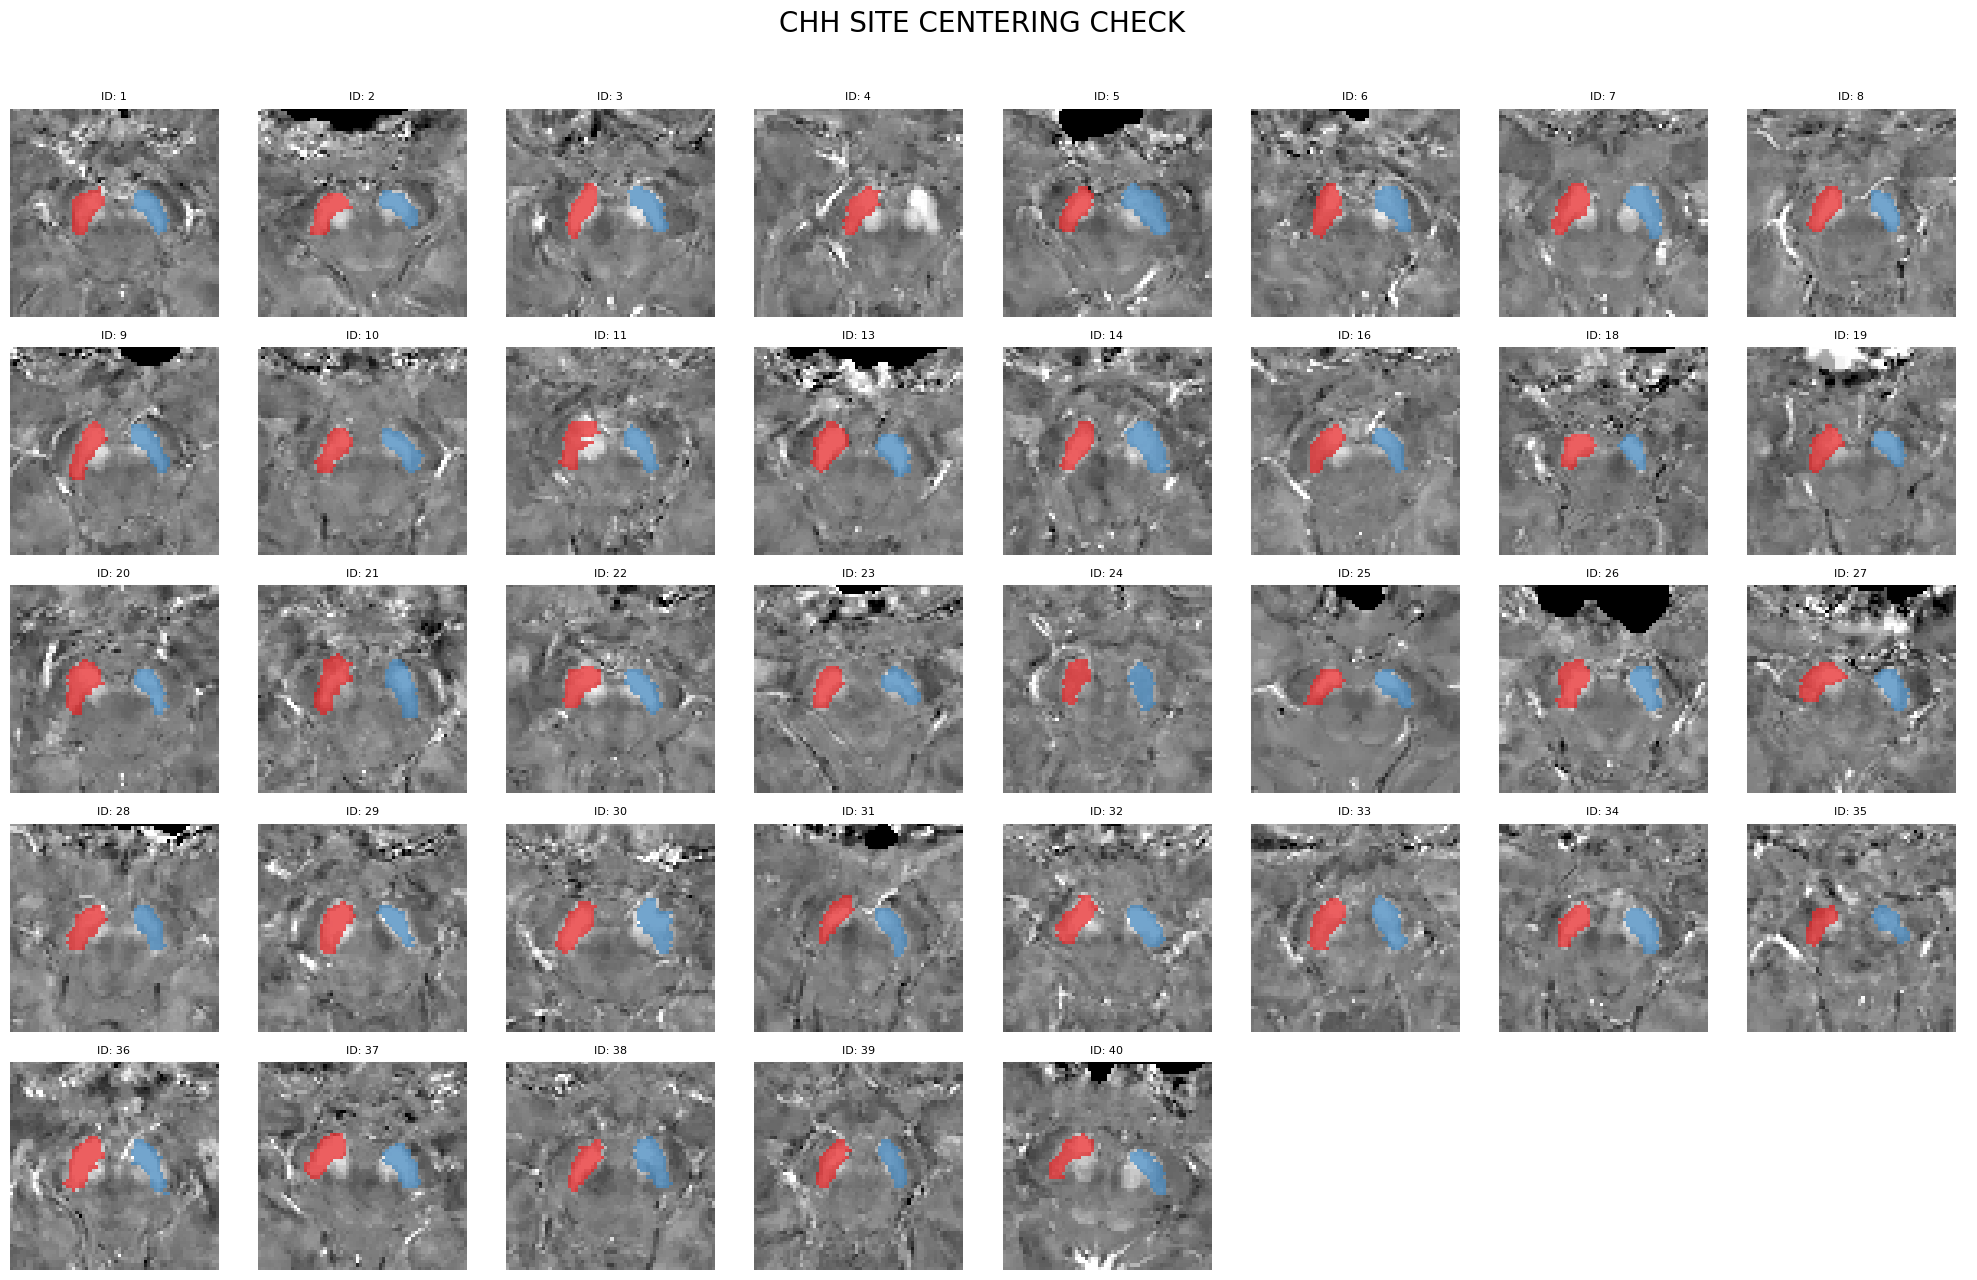

>>> Generating MSW grid for 111 subjects...


100%|██████████| 111/111 [12:36<00:00,  6.82s/it]


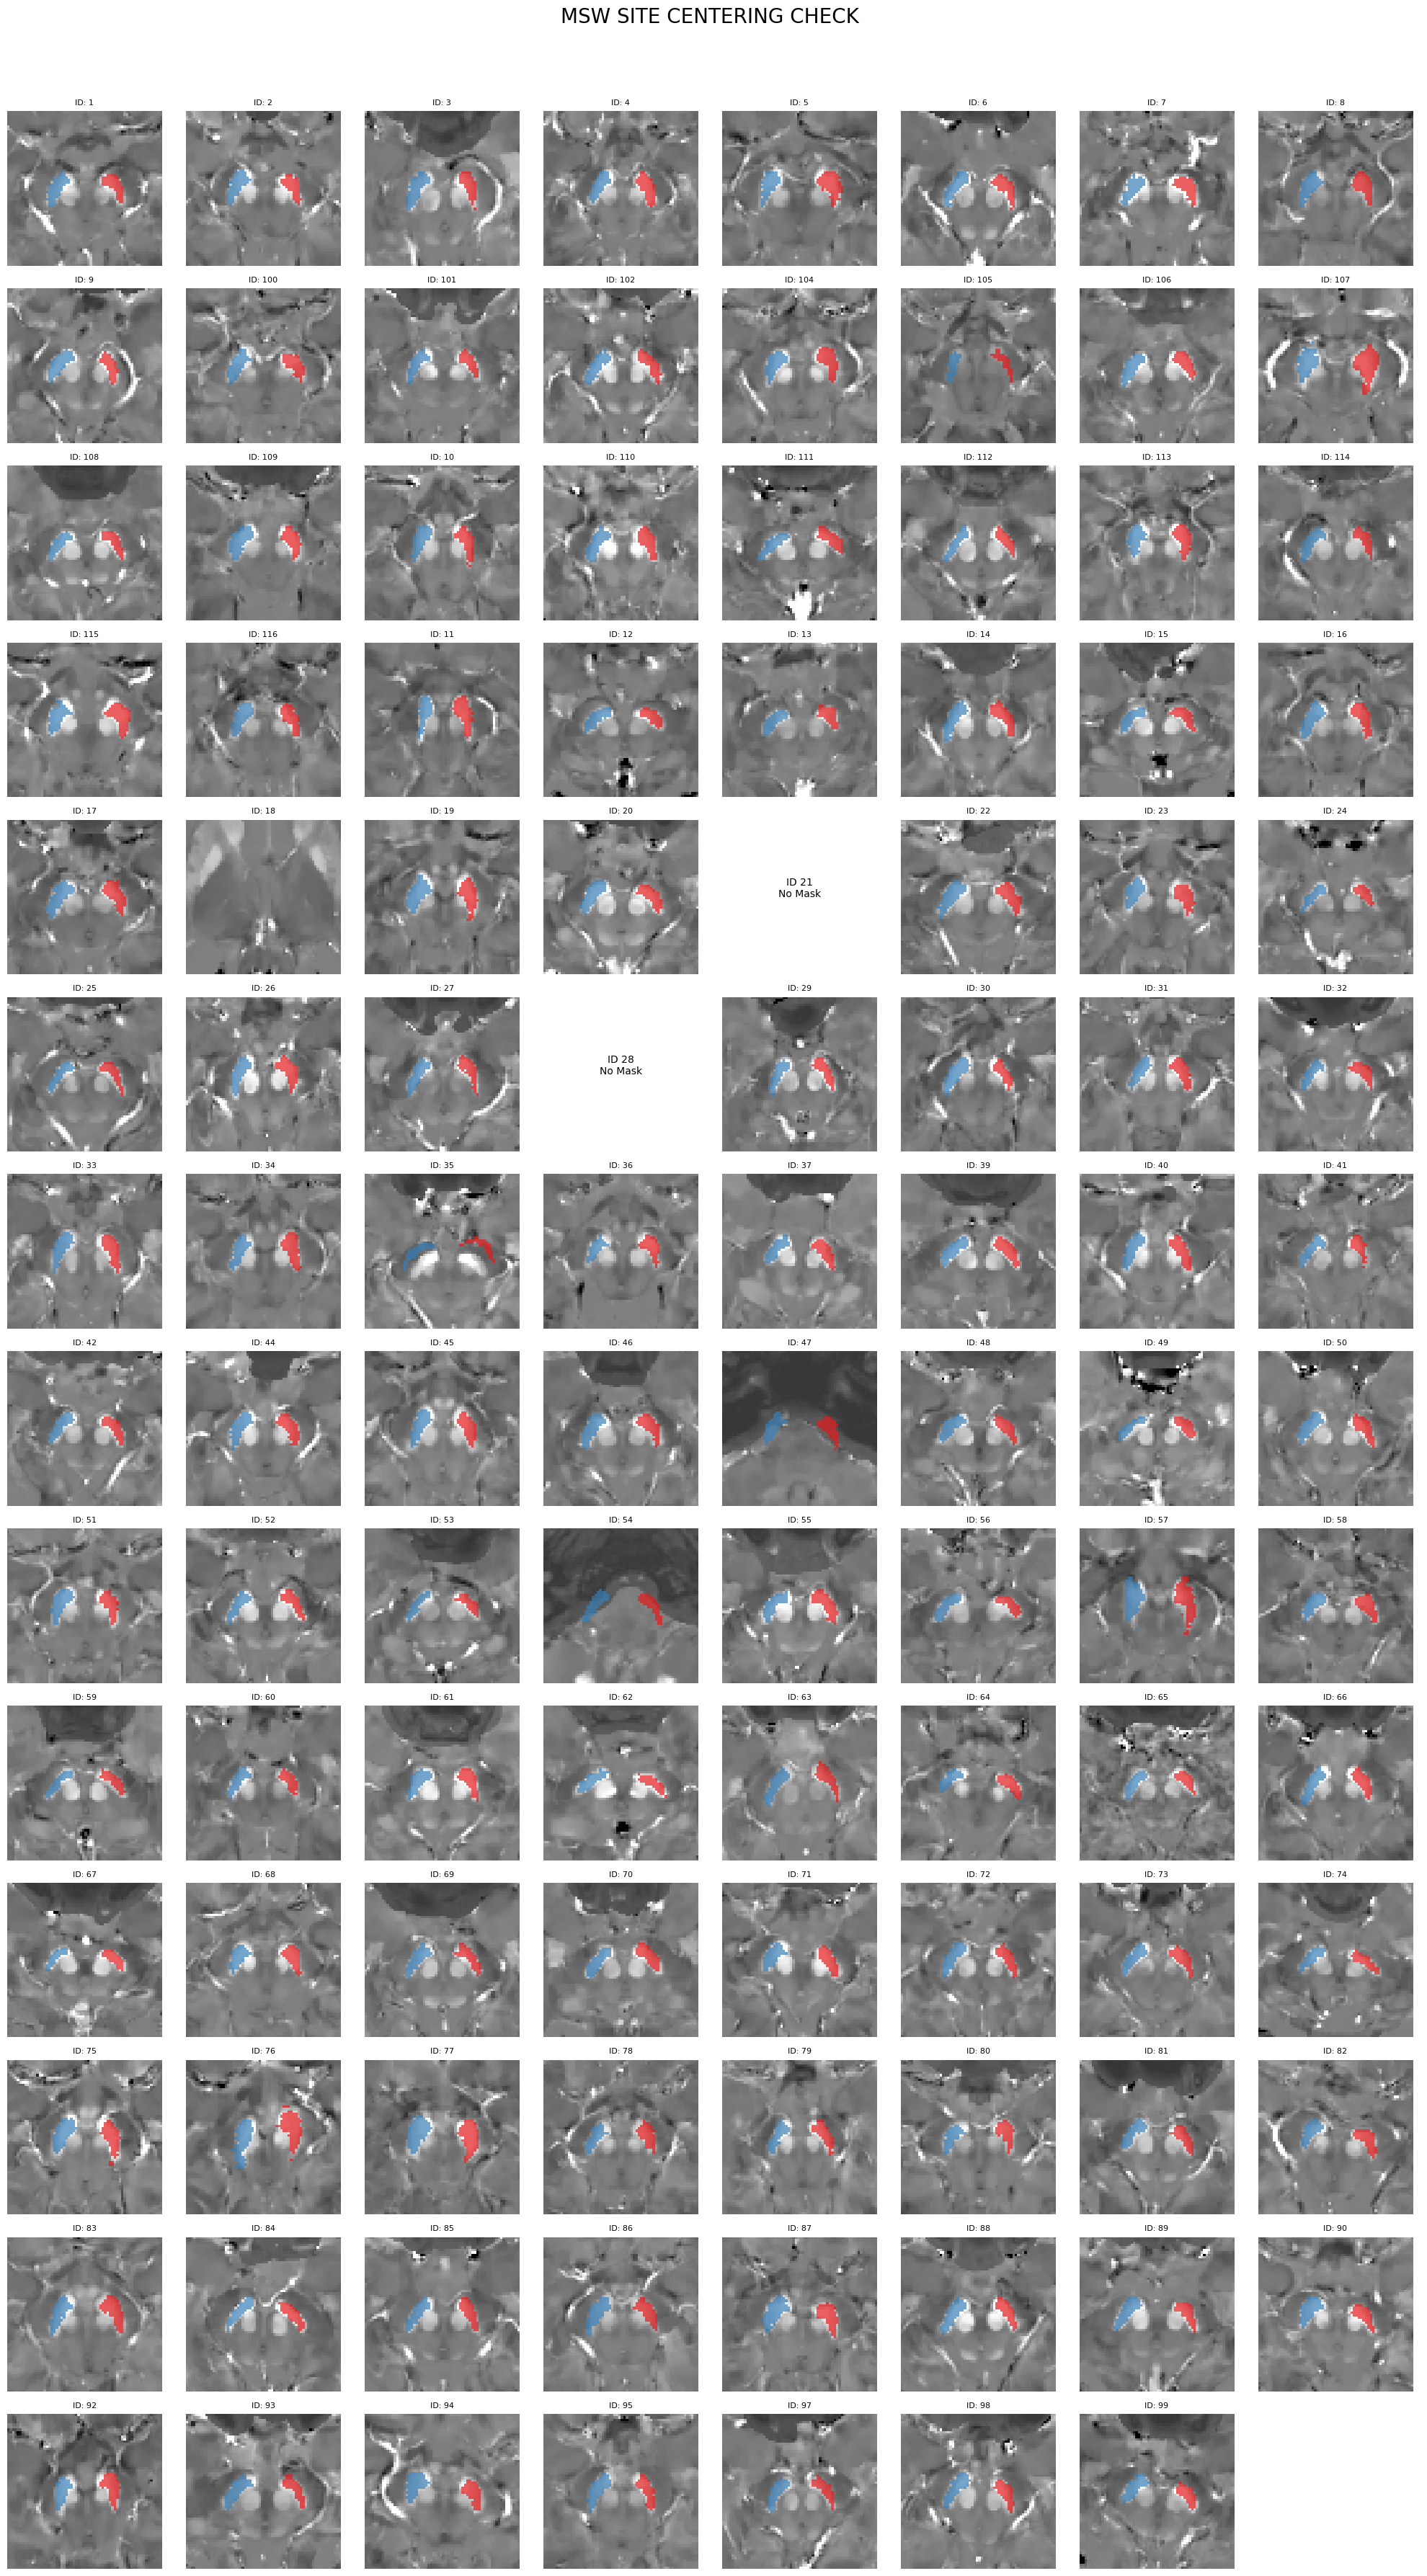

In [3]:
import math
import os
import re
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from tqdm import tqdm

# --- Settings ---
MSW_IMG_DIR = '/media/mts_dbs/dbs/all/nii/qsm_115/im'
MSW_SEG_DIR = '/media/mts_dbs/dbs/all/nii/seg_ps/'
CHH_IMG_DIR = '/media/mts_dbs/chh/nii/qsm/'
CHH_SEG_DIR = '/media/mts_dbs/chh/nii/roi/'

def plot_site_grid(img_dir, seg_dir, mode, cols=8, num_to_show=None):
    files = sorted([f for f in os.listdir(img_dir) if f.endswith('.nii.gz')])
    if num_to_show:
        files = files[:num_to_show]
        
    num_files = len(files)
    rows = math.ceil(num_files / cols)
    
    # Large figure size to ensure each subplot is clear
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    axes = axes.flatten()
    
    print(f">>> Generating {mode} grid for {num_files} subjects...")

    for i, f in enumerate(tqdm(files)):
        try:
            # 1. Load Data (Exact Debug Logic)
            img_data = np.nan_to_num(nib.load(os.path.join(img_dir, f)).get_fdata())
            
            match = re.search(r'\d+', f)
            sub_id_int = int(match.group())
            
            if mode == 'MSW':
                mask_name = f"seg_{sub_id_int:02d}.nii.gz"
            else:
                mask_name = f"{sub_id_int:02d}_roi_combined.nii"
                if not os.path.exists(os.path.join(seg_dir, mask_name)):
                    mask_name = f"{sub_id_int}_roi_combined.nii"

            mask_path = os.path.join(seg_dir, mask_name)
            if not os.path.exists(mask_path) and os.path.exists(mask_path + ".gz"):
                mask_path += ".gz"
            
            if not os.path.exists(mask_path):
                axes[i].text(0.5, 0.5, f"ID {sub_id_int}\nNo Mask", ha='center')
                axes[i].axis('off')
                continue

            msk_data = nib.load(mask_path).get_fdata()

            # 2. Site-Specific Anchoring
            anchors = [5, 6] if mode == 'MSW' else [1, 4]
            coords = np.argwhere(np.isin(msk_data, anchors))
            if len(coords) == 0:
                coords = np.argwhere(msk_data > 0)

            cz, cy, cx = coords.mean(axis=0).astype(int)
            hz, hy, hx = (58, 58, 64) if mode == 'MSW' else (32, 32, 36)

            # 3. Extract and Resample
            img_crop = img_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]
            msk_crop = msk_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]

            if mode == 'MSW':
                res_ratio = 0.5 / 0.9
                img_f = zoom(img_crop, (res_ratio, res_ratio, 1.0), order=1)
                msk_f = zoom(msk_crop, (res_ratio, res_ratio, 1.0), order=0)
            else:
                img_f, msk_f = img_crop, msk_crop

            # 4. Plot (Directly from img_f)
            mid = img_f.shape[2] // 2
            axes[i].imshow(np.rot90(img_f[:, :, mid]), cmap='gray', vmin=-250, vmax=250)
            
            # Overlay
            mask_overlay = np.rot90(msk_f[:, :, mid])
            display_mask = np.zeros_like(mask_overlay)
            if mode == 'MSW':
                display_mask[mask_overlay == 5] = 1
                display_mask[mask_overlay == 6] = 2
            else:
                display_mask[mask_overlay == 1] = 1
                display_mask[mask_overlay == 4] = 2
                
            if np.any(display_mask > 0):
                masked_data = np.ma.masked_where(display_mask == 0, display_mask)
                axes[i].imshow(masked_data, cmap='Set1', alpha=0.7, vmin=1, vmax=8)
            
            axes[i].set_title(f"ID: {sub_id_int}", fontsize=8)
            axes[i].axis('off')
            
        except Exception as e:
            axes[i].text(0.5, 0.5, "Err", ha='center', color='red')
            axes[i].axis('off')

    # Cleanup unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"{mode} SITE CENTERING CHECK", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# --- RUN GRIDS ---

# Plot all CHH cases first
plot_site_grid(CHH_IMG_DIR, CHH_SEG_DIR, 'CHH', cols=8)

# Plot MSW cases (showing first 64 to keep the grid manageable, or remove num_to_show for all)
plot_site_grid(MSW_IMG_DIR, MSW_SEG_DIR, 'MSW', cols=8, num_to_show=111)

ID 4 Unique Labels: [0. 1. 2. 3. 4. 5. 6.]
Label 1 voxel count: 685
Label 4 voxel count: 167


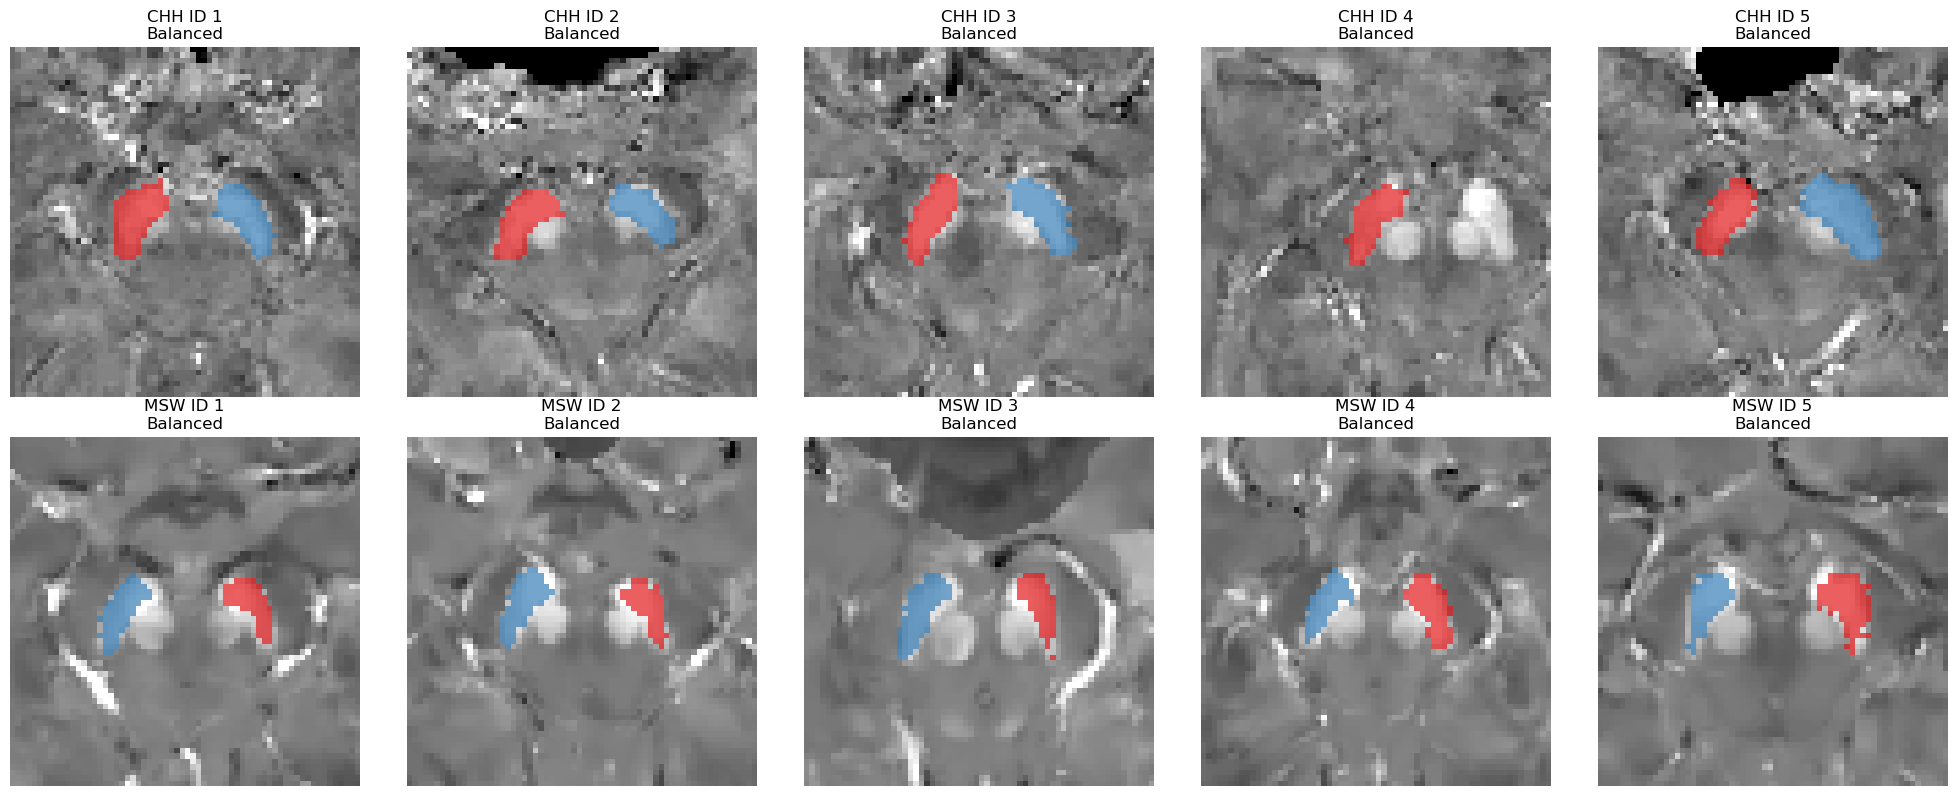

In [4]:
import numpy as np
import nibabel as nib

# Path for CHH ID 4
test_path = '/media/mts_dbs/chh/nii/roi/04_roi_combined.nii'
# Handle potential .gz extension
if not os.path.exists(test_path): test_path += '.gz'

if os.path.exists(test_path):
    msk = nib.load(test_path).get_fdata()
    labels = np.unique(msk)
    print(f"ID 4 Unique Labels: {labels}")
    
    for l in [1, 4]: # CHH SN Labels
        count = np.sum(msk == l)
        print(f"Label {l} voxel count: {count}")
else:
    print("File not found.")

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import os
import re

# Settings
MSW_IMG_DIR = '/media/mts_dbs/dbs/all/nii/qsm_115/im'
MSW_SEG_DIR = '/media/mts_dbs/dbs/all/nii/seg_ps/'
CHH_IMG_DIR = '/media/mts_dbs/chh/nii/qsm/'
CHH_SEG_DIR = '/media/mts_dbs/chh/nii/roi/'

def check_balanced_centering(num_cases=5):
    sites = [
        ('CHH', CHH_IMG_DIR, CHH_SEG_DIR, [1, 4]),
        ('MSW', MSW_IMG_DIR, MSW_SEG_DIR, [5, 6])
    ]
    
    fig, axes = plt.subplots(2, num_cases, figsize=(num_cases * 4, 8))
    
    for row_idx, (mode, img_dir, seg_dir, anchors) in enumerate(sites):
        files = sorted([f for f in os.listdir(img_dir) if f.endswith('.nii.gz')])[:num_cases]
        
        for col_idx, f in enumerate(files):
            # 1. Load Data
            match = re.search(r'\d+', f)
            sub_id = int(match.group())
            
            img_path = os.path.join(img_dir, f)
            mask_name = f"seg_{sub_id:02d}.nii.gz" if mode == 'MSW' else f"{sub_id:02d}_roi_combined.nii"
            mask_path = os.path.join(seg_dir, mask_name)
            if not os.path.exists(mask_path): mask_path += ".gz"
            
            img_data = np.nan_to_num(nib.load(img_path).get_fdata())
            msk_data = nib.load(mask_path).get_fdata()

            # 2. BALANCED CENTERING LOGIC
            side1_coords = np.argwhere(msk_data == anchors[0])
            side2_coords = np.argwhere(msk_data == anchors[1])

            if len(side1_coords) > 0 and len(side2_coords) > 0:
                # Midpoint between the centers of both ROIs
                c1 = side1_coords.mean(axis=0)
                c2 = side2_coords.mean(axis=0)
                cz, cy, cx = ((c1 + c2) / 2).astype(int)
                status = "Balanced"
            else:
                # Fallback if one ROI is missing
                all_coords = np.argwhere(np.isin(msk_data, anchors))
                if len(all_coords) == 0: all_coords = np.argwhere(msk_data > 0)
                cz, cy, cx = all_coords.mean(axis=0).astype(int)
                status = "Mass-Mean"

            # 3. Radius and Extract
            hz, hy, hx = (58, 58, 64) if mode == 'MSW' else (32, 32, 36)
            img_crop = img_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]
            msk_crop = msk_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]

            # 4. Resample MSW
            if mode == 'MSW':
                res_ratio = 0.5 / 0.9
                img_f = zoom(img_crop, (res_ratio, res_ratio, 1.0), order=1)
                msk_f = zoom(msk_crop, (res_ratio, res_ratio, 1.0), order=0)
            else:
                img_f, msk_f = img_crop, msk_crop

            # 5. Plot
            ax = axes[row_idx, col_idx]
            mid = img_f.shape[2] // 2
            ax.imshow(np.rot90(img_f[:, :, mid]), cmap='gray', vmin=-250, vmax=250)
            
            # Overlay
            mask_slice = np.rot90(msk_f[:, :, mid])
            ov = np.zeros_like(mask_slice)
            ov[mask_slice == anchors[0]] = 1
            ov[mask_slice == anchors[1]] = 2
            
            if np.any(ov > 0):
                ax.imshow(np.ma.masked_where(ov == 0, ov), cmap='Set1', alpha=0.7, vmin=1, vmax=8)
            
            ax.set_title(f"{mode} ID {sub_id}\n{status}")
            ax.axis('off')

    plt.tight_layout()
    plt.show()

check_balanced_centering(5)

MSW unique labels: [1. 2. 5. 6. 7. 8.]
MSW Center derived from [5, 6]: (256, 236, 144)
CHH unique labels: [1. 2. 3. 4. 5. 6.]
CHH Center derived from [1, 4]: (126, 131, 52)


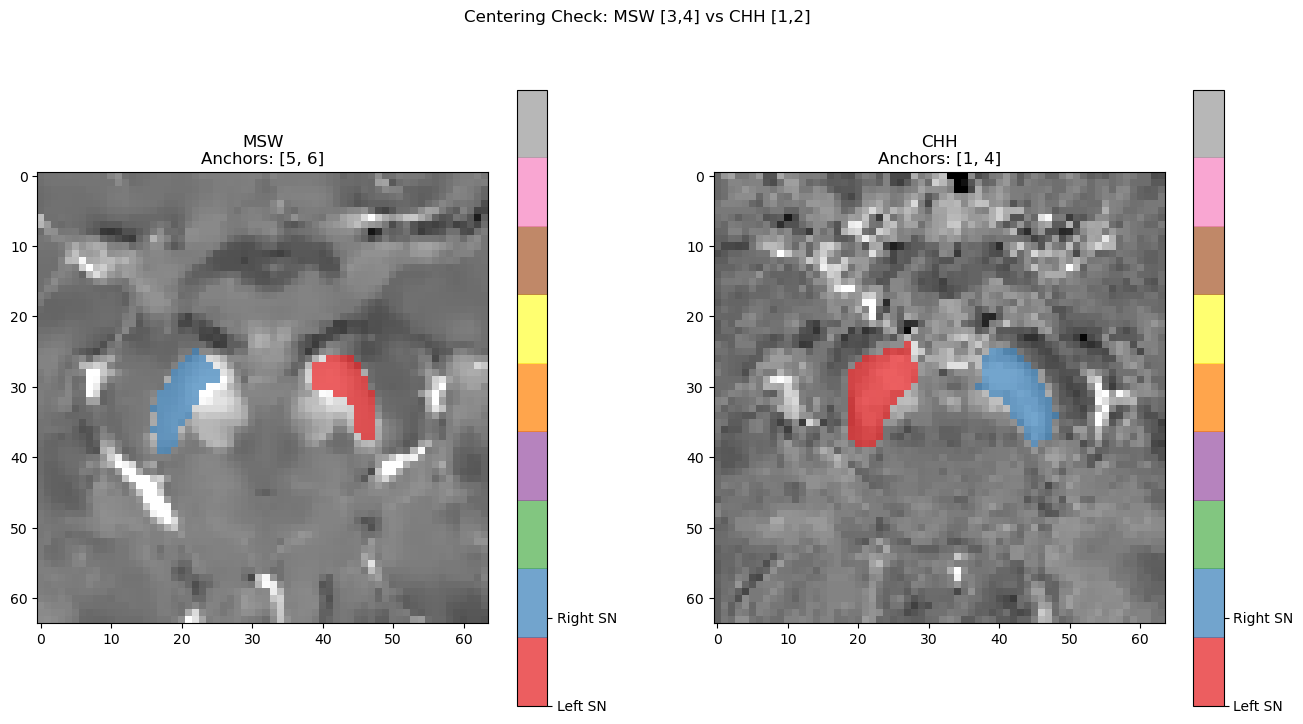

In [5]:
import numpy as np
import nibabel as nib
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
test_msw_img = '/media/mts_dbs/dbs/all/nii/qsm_115/im/qsm_01_e10_imaginary.nii.gz'
test_msw_seg = '/media/mts_dbs/dbs/all/nii/seg_ps/seg_01.nii.gz'
test_chh_img = '/media/mts_dbs/chh/nii/qsm/00001_qsm.nii.gz'
test_chh_seg ='/media/mts_dbs/chh/nii/roi/01_roi_combined.nii'


def debug_centering_on_shared_anatomy(msw_paths, chh_paths):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    pairs = [(msw_paths, 'MSW'), (chh_paths, 'CHH')]

    for i, (paths, mode) in enumerate(pairs):
        img_p, msk_p = paths
        img_data = np.nan_to_num(nib.load(img_p).get_fdata())
        msk_data = nib.load(msk_p).get_fdata()

        # 1. IDENTIFY LABELS
        u_labels = np.unique(msk_data)
        u_labels = u_labels[u_labels > 0]
        print(f"{mode} unique labels: {u_labels}")

        # 2. SITE-SPECIFIC ANCHORING
        # MSW: Use 2 and 4 | CHH: Use 1 and 2
        anchors = [5, 6] if mode == 'MSW' else [1, 4]
        target_coords = np.argwhere(np.isin(msk_data, anchors))
        
        if len(target_coords) == 0:
            print(f"WARNING: {mode} missing anchors {anchors}! Falling back.")
            coords = np.argwhere(msk_data > 0)
        else:
            coords = target_coords

        cz, cy, cx = coords.mean(axis=0).astype(int)
        print(f"{mode} Center derived from {anchors}: {cz, cy, cx}")

        # 3. Scale-Matched Radius
        hz, hy, hx = (58, 58, 64) if mode == 'MSW' else (32, 32, 36)
        
        # 4. Extract
        img_crop = img_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]
        msk_crop = msk_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]
        
        # 5. Resample MSW for size parity
        if mode == 'MSW':
            res_ratio = 0.5 / 0.9
            img_f = zoom(img_crop, (res_ratio, res_ratio, 1.0), order=1)
            msk_f = zoom(msk_crop, (res_ratio, res_ratio, 1.0), order=0)
        else:
            img_f, msk_f = img_crop, msk_crop
            
        # 6. Plot middle slice
        mid = img_f.shape[2] // 2
        axes[i].imshow(np.rot90(img_f[:, :, mid]), cmap='gray', vmin=-250, vmax=250)
        
        # 7. SITE-SPECIFIC OVERLAY
        # We remap labels so they share the same colorbar (0=bg, 1=Left, 2=Right)
        mask_overlay = np.rot90(msk_f[:, :, mid])
        display_mask = np.zeros_like(mask_overlay)
        
        if mode == 'MSW':
            display_mask[mask_overlay == 5] = 1 # Remap MSW 2 -> Colormap 1
            display_mask[mask_overlay == 6] = 2 # Remap MSW 4 -> Colormap 2
        else:
            display_mask[mask_overlay == 1] = 1 # Remap CHH 1 -> Colormap 1
            display_mask[mask_overlay == 4] = 2 # Remap CHH 2 -> Colormap 2
            
        masked_data = np.ma.masked_where(display_mask == 0, display_mask)
        
        # Use a qualitative map like 'Set1' or 'vivid'
        im = axes[i].imshow(masked_data, cmap='Set1', alpha=0.7, vmin=1, vmax=8)
        axes[i].set_title(f"{mode}\nAnchors: {anchors}")
        
        # Standardized colorbar for the two structures
        cbar = plt.colorbar(im, ax=axes[i], ticks=[1, 2])
        cbar.ax.set_yticklabels(['Left SN', 'Right SN'])

    plt.suptitle("Centering Check: MSW [3,4] vs CHH [1,2]")
    plt.show()

# Run it
debug_centering_on_shared_anatomy((test_msw_img, test_msw_seg), (test_chh_img, test_chh_seg))